In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from qiskit_finance.applications import PortfolioOptimization
from qiskit_algorithms import NumPyMinimumEigensolver, QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler
from qiskit_optimization.algorithms import MinimumEigenOptimizer

In [2]:
np.random.seed(42)
num_assets = 3
num_ticks = 100

true_cov = np.array([
    [0.00010, 0.00002, 0.00001],
    [0.00002, 0.00040, 0.00005],
    [0.00001, 0.00005, 0.00020]
])

true_mu = np.array([
    0.0005, 0.001, 0.0008
])

returns = np.random.multivariate_normal(true_mu, true_cov, num_ticks)
print(f"{returns[:3]}\n")

price_paths = np.cumprod(1 + returns, axis=0) * 100
print(f"{price_paths[:3]}\n")

mu = np.mean(returns, axis = 0)
sigma = np.cov(returns.T)
print(f"mu: {mu} \n\nsigma: {sigma}")

[[-0.0066999  -0.00800731 -0.00291508]
 [ 0.00048256 -0.02842248 -0.00962929]
 [ 0.00350449 -0.03288547  0.00328503]]

[[99.33000961 99.1992691  99.70849155]
 [99.37794276 96.37978026 98.74836929]
 [99.72621174 93.21028606 99.07276105]]

mu: [-0.00051019 -0.00017993 -0.00201885] 

sigma: [[ 1.21651763e-04 -1.54666122e-05  1.93164746e-05]
 [-1.54666122e-05  2.72989862e-04  3.31693726e-05]
 [ 1.93164746e-05  3.31693726e-05  1.88848871e-04]]


In [3]:
q = 0.5
budget = 2

portfolio = PortfolioOptimization(
    expected_returns = mu,
    covariances = sigma,
    risk_factor = q,
    budget = budget
)

qp = portfolio.to_quadratic_program()
print("Quadratic Program Formulation:\n", qp)

Quadratic Program Formulation:
 minimize 6.082588139580539e-05*x_0^2 - 1.5466612189211075e-05*x_0*x_1 + 1.931647461490073e-05*x_0*x_2 + 0.00013649493099915342*x_1^2 + 3.3169372555213784e-05*x_1*x_2 + 9.442443563306412e-05*x_2^2 + 0.0005101867464330037*x_0 + 0.00017992987856972197*x_1 + 0.0020188516786747318*x_2 (3 variables, 1 constraints, 'Portfolio optimization')


In [4]:
# classical solver

exact_mes = NumPyMinimumEigensolver()
exact_optimizer = MinimumEigenOptimizer(exact_mes)

start_time = time.time()
exact_result = exact_optimizer.solve(qp)
exact_time = time.time() - start_time

In [5]:
# quantum approximate optimization algorithm
# Speed knobs (trade accuracy vs time):
#   reps   — QAOA layers; 1 is much faster than 2–3 for small problems.
#   maxiter — COBYLA budget; 50–150 is often enough for 3 binary vars.

sampler = StatevectorSampler()
cobyla = COBYLA(maxiter=100)  # was 250; raise if solution quality drops
qaoa = QAOA(sampler=sampler, optimizer=cobyla, reps=1)  # was 3; increase for harder problems
qaoa_optimizer = MinimumEigenOptimizer(qaoa)

start_time = time.time()
qaoa_result = qaoa_optimizer.solve(qp)
qaoa_time = time.time() - start_time

c:\Users\ofurn\Dokumenter\Github\fys5419\.venv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\ofurn\Dokumenter\Github\fys5419\.venv\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
c:\Users\ofurn\Dokumenter\Github\fys5419\.venv\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [6]:
print("\n--- Results ---")
print(f"Classical Exact Solution: {exact_result.x} (Found in {exact_time:.4f} sec)")
print(f"QAOA Solution:            {qaoa_result.x} (Found in {qaoa_time:.4f} sec)")


--- Results ---
Classical Exact Solution: [1. 1. 0.] (Found in 0.0440 sec)
QAOA Solution:            [1. 1. 0.] (Found in 2.3545 sec)


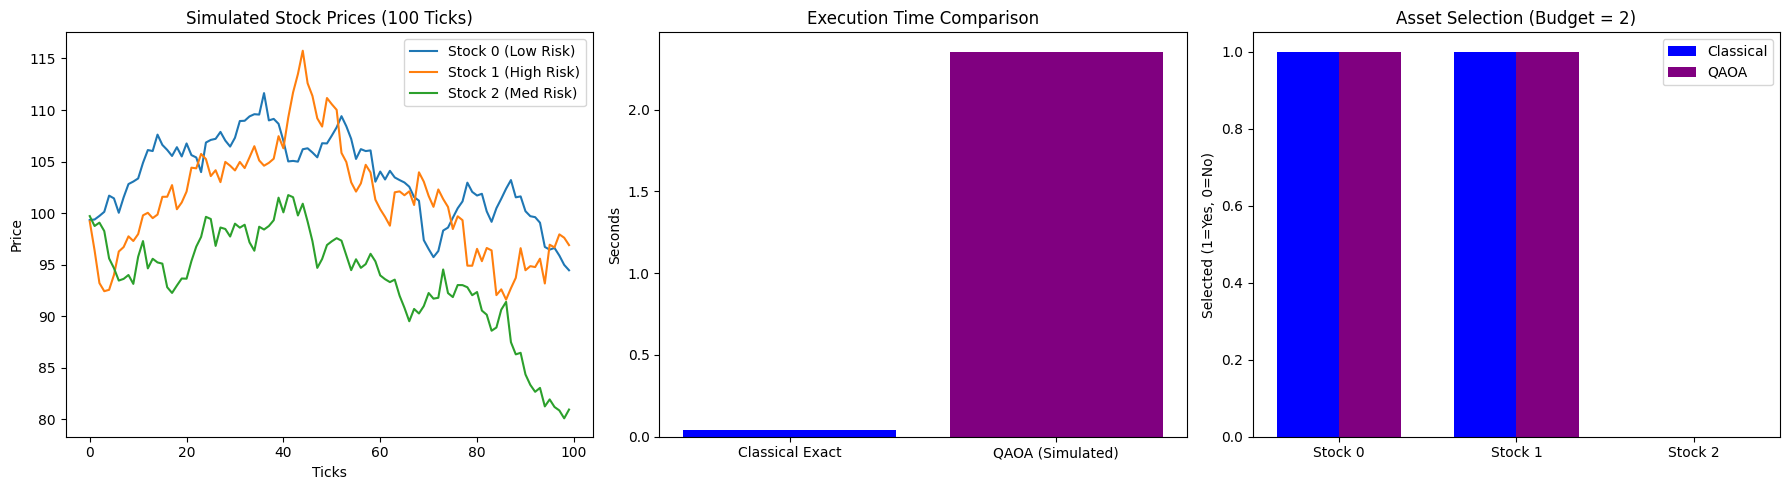

In [7]:
# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Stock Price Paths
axes[0].plot(price_paths[:, 0], label='Stock 0 (Low Risk)')
axes[0].plot(price_paths[:, 1], label='Stock 1 (High Risk)')
axes[0].plot(price_paths[:, 2], label='Stock 2 (Med Risk)')
axes[0].set_title('Simulated Stock Prices (100 Ticks)')
axes[0].set_xlabel('Ticks')
axes[0].set_ylabel('Price')
axes[0].legend()

# Plot 2: Speed Comparison
# Note: QAOA will be heavily disadvantaged here because simulating quantum circuits 
# on classical hardware has overhead, and N=3 is trivial for classical CPU.
solvers = ['Classical Exact', 'QAOA (Simulated)']
times = [exact_time, qaoa_time]
axes[1].bar(solvers, times, color=['blue', 'purple'])
axes[1].set_title('Execution Time Comparison')
axes[1].set_ylabel('Seconds')

# Plot 3: Chosen Portfolio
stocks = ['Stock 0', 'Stock 1', 'Stock 2']
x_indexes = np.arange(len(stocks))
width = 0.35

axes[2].bar(x_indexes - width/2, exact_result.x, width, label='Classical', color='blue')
axes[2].bar(x_indexes + width/2, qaoa_result.x, width, label='QAOA', color='purple')
axes[2].set_title(f'Asset Selection (Budget = {budget})')
axes[2].set_xticks(x_indexes)
axes[2].set_xticklabels(stocks)
axes[2].set_ylabel('Selected (1=Yes, 0=No)')
axes[2].legend()

plt.tight_layout()
plt.show()